# ZORC P11a — SQL Exploration with DuckDB

This notebook uses **DuckDB** to query the ZORC SQLite relational database (`data/zorc_database.db`)
and demonstrates advanced SQL: window functions, CTEs, aggregations.

All queries are taken from `docs/ZORC_P10_P14_architecture.md §P11a`.

| Query | Purpose |
|---|---|
| Q1 | Top 20 P-body candidates by model probability |
| Q2 | Feature distributions by class — window functions |
| Q3 | High N/C flexibility asymmetry AND high m6A density |
| Q4 | Xenium probe panel candidates (prob > 0.85, rrach_count > 15) |
| Q5 | Label noise — ambiguous negatives |
| Q6 | Model performance by BioEmu tier |


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DB = '../data/zorc_database.db'

def sql(query: str, db: str = DB) -> pd.DataFrame:
    """Execute a SQL query via DuckDB against the SQLite file."""
    con = duckdb.connect()
    # DuckDB can attach SQLite files directly
    con.execute(f"ATTACH '{db}' AS zorc (TYPE SQLITE)")
    result = con.execute(query).df()
    con.close()
    return result

print('DuckDB version:', duckdb.__version__)

DuckDB version: 1.5.2


## Database overview

In [2]:
overview = sql("""
SELECT
    (SELECT COUNT(*) FROM zorc.genes)       AS n_genes,
    (SELECT COUNT(*) FROM zorc.features)    AS n_features_rows,
    (SELECT COUNT(*) FROM zorc.predictions) AS n_predictions,
    (SELECT SUM(class) FROM zorc.genes)     AS n_positives,
    (SELECT COUNT(*) - SUM(class) FROM zorc.genes) AS n_negatives
""")
print(overview.to_string(index=False))

 n_genes  n_features_rows  n_predictions  n_positives  n_negatives
    1501             1501           1501        880.0        621.0


---
## Q1 — Top 20 P-body candidates by model probability

In [3]:
q1 = sql("""
SELECT
    g.gene_id,
    g.gene_name,
    p.prob_pos,
    f.rrach_count,
    ROUND(f.idr_percent, 1)          AS idr_pct,
    ROUND(f.utr3_au_content, 3)      AS utr3_au,
    ROUND(f.rmsf_nterm_cterm_ratio, 2) AS rmsf_ratio
FROM zorc.predictions p
JOIN zorc.genes g USING (gene_id)
JOIN zorc.features f USING (gene_id)
WHERE g.class = 1
ORDER BY p.prob_pos DESC
LIMIT 20;
""")
q1

,gene_id,gene_name,prob_pos,rrach_count,idr_pct,utr3_au,rmsf_ratio
0,AT3G54230,SUA,0.938071,55.0,79.7,0.698,1.42
1,AT5G64220,AT5G64220,0.937147,49.0,28.4,0.670,1.01
2,AT5G19420,AT5G19420,0.935925,50.0,40.4,0.674,1.09
3,AT4G30100,AT4G30100,0.935577,56.0,42.0,0.603,0.85
4,AT5G08390,AT5G08390,0.935385,36.0,45.9,0.606,0.67
5,AT1G17210,ILP1,0.935150,40.0,66.2,0.682,1.59
6,AT2G36480,AT2G36480,0.934018,44.0,59.8,0.632,1.63
7,AT2G40140,CZF1,0.933432,30.0,47.2,0.686,0.49
8,AT4G14990,AT4G14990,0.932944,39.0,53.4,0.630,2.66
9,AT4G11860,AT4G11860,0.931110,29.0,57.2,0.657,0.69


---
## Q2 — Feature distributions by class using window functions

Quartile assignment for `utr3_au_content` + mean probability per quartile.

In [4]:
q2 = sql("""
WITH base AS (
    SELECT
        g.gene_id,
        g.class,
        f.utr3_au_content,
        p.prob_pos,
        NTILE(4) OVER (ORDER BY f.utr3_au_content) AS au_quartile
    FROM zorc.features f
    JOIN zorc.genes g USING (gene_id)
    JOIN zorc.predictions p USING (gene_id)
    WHERE f.utr3_au_content IS NOT NULL
)
SELECT
    au_quartile,
    COUNT(*)                  AS n_genes,
    SUM(class)                AS n_positives,
    ROUND(AVG(utr3_au_content), 3) AS mean_utr3_au,
    ROUND(AVG(prob_pos), 3)   AS mean_prob_pos
FROM base
GROUP BY au_quartile
ORDER BY au_quartile;
""")
q2

,au_quartile,n_genes,n_positives,mean_utr3_au,mean_prob_pos
0,1,376,190.0,0.591,0.513
1,2,375,256.0,0.656,0.656
2,3,375,241.0,0.684,0.627
3,4,375,193.0,0.728,0.519


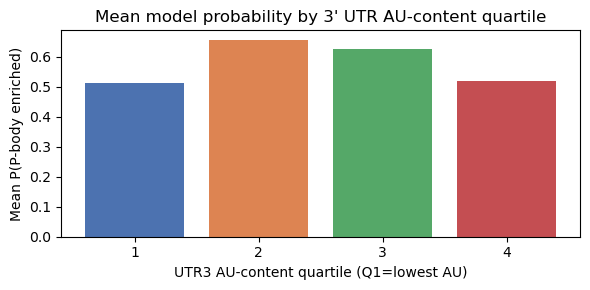

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(q2['au_quartile'], q2['mean_prob_pos'], color=['#4C72B0','#DD8452','#55A868','#C44E52'])
ax.set_xlabel('UTR3 AU-content quartile (Q1=lowest AU)')
ax.set_ylabel('Mean P(P-body enriched)')
ax.set_title('Mean model probability by 3\' UTR AU-content quartile')
ax.set_xticks([1,2,3,4])
plt.tight_layout()
plt.show()

In [ ]:
# Diagnóstico: distribución real de rmsf_nterm_cterm_ratio y rrach_per_kb
q_diag = sql("""
SELECT 
    ROUND(MIN(f.rmsf_nterm_cterm_ratio), 2) AS rmsf_ratio_min,
    ROUND(MAX(f.rmsf_nterm_cterm_ratio), 2) AS rmsf_ratio_max,
    ROUND(AVG(f.rmsf_nterm_cterm_ratio), 2) AS rmsf_ratio_mean,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY f.rmsf_nterm_cterm_ratio) AS rmsf_ratio_p75,
    ROUND(MIN(f.rrach_per_kb), 2) AS rrach_kb_min,
    ROUND(MAX(f.rrach_per_kb), 2) AS rrach_kb_max,
    ROUND(AVG(f.rrach_per_kb), 2) AS rrach_kb_mean,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY f.rrach_per_kb) AS rrach_kb_p75,
    COUNT(*) FILTER (WHERE f.rmsf_nterm_cterm_ratio > 2.0) AS n_high_rmsf,
    COUNT(*) FILTER (WHERE f.rrach_per_kb > 15.0) AS n_high_rrach,
    COUNT(*) FILTER (WHERE f.rmsf_nterm_cterm_ratio > 2.0 
                     AND f.rrach_per_kb > 15.0) AS n_both
FROM zorc.features f
""")
print(q_diag.to_string(index=False))

---
## Q3 — High N/C flexibility asymmetry AND high m6A density

Biologically: proteins with exposed N-termini (`rmsf_nterm > 2× rmsf_cterm`) AND
multiple m6A sites (`rrach_per_kb > 30`) — strong P-body signal combination.

In [ ]:
q3 = sql("""
SELECT
    g.gene_id,
    g.gene_name,
    g.class,
    ROUND(f.rmsf_nterm_cterm_ratio, 2) AS rmsf_ratio,
    ROUND(f.rrach_per_kb, 1)           AS rrach_per_kb,
    ROUND(f.idr_percent, 1)            AS idr_pct,
    ROUND(p.prob_pos, 3)               AS prob_pos
FROM zorc.features f
JOIN zorc.genes g USING (gene_id)
JOIN zorc.predictions p USING (gene_id)
WHERE f.rmsf_nterm_cterm_ratio > 2.0
  AND f.rrach_per_kb > 15.0
  AND f.rmsf_nterm_cterm_ratio IS NOT NULL
  AND f.rrach_per_kb IS NOT NULL
ORDER BY p.prob_pos DESC;
""")
print(f'{len(q3)} genes with rmsf_ratio > 2 AND rrach_per_kb > 15')
q3.head(20)

---
## Q4 — Xenium probe panel candidates

High-confidence P-body mRNA candidates for spatial transcriptomics probe design.
Criteria: `prob_pos > 0.85` AND `rrach_count > 15`.

In [ ]:
q4 = sql("""
WITH ranked AS (
    SELECT
        g.gene_id,
        g.gene_name,
        g.condition,
        ROUND(p.prob_pos, 3)          AS prob_pos,
        f.rrach_count,
        ROUND(f.utr3_au_content, 3)   AS utr3_au,
        ROUND(f.idr_percent, 1)       AS idr_pct,
        ROW_NUMBER() OVER (ORDER BY p.prob_pos DESC) AS rank
    FROM zorc.predictions p
    JOIN zorc.genes g USING (gene_id)
    JOIN zorc.features f USING (gene_id)
    WHERE p.prob_pos > 0.85
      AND f.rrach_count > 15
)
SELECT * FROM ranked
ORDER BY rank
LIMIT 50;
""")
print(f'{len(q4)} Xenium probe candidates (prob > 0.85 AND rrach_count > 15)')
q4

In [ ]:
# Export for probe design submission
q4.to_csv('../results/11a_xenium_probe_candidates.csv', index=False)
print('Saved: results/11a_xenium_probe_candidates.csv')

---
## Q5 — Label noise analysis — ambiguous negatives

Genes labeled `class=0` (depleted) but predicted P-body enriched with
probability 0.35–0.65. These are the most likely label-noise candidates.

In [ ]:
q5 = sql("""
SELECT
    g.gene_id,
    g.gene_name,
    g.condition,
    ROUND(p.prob_pos, 3)            AS prob_pos,
    ROUND(f.utr3_au_content, 3)     AS utr3_au,
    f.rrach_count,
    ROUND(f.idr_percent, 1)         AS idr_pct,
    g.bioemu_tier
FROM zorc.predictions p
JOIN zorc.genes g USING (gene_id)
JOIN zorc.features f USING (gene_id)
WHERE g.class = 0
  AND p.prob_pos BETWEEN 0.35 AND 0.65
ORDER BY p.prob_pos DESC;
""")
print(f'{len(q5)} ambiguous negatives (class=0, prob 0.35–0.65)')
print(f'These represent {len(q5)/688*100:.1f}% of all negatives')
q5.head(20)

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(q5['prob_pos'], bins=20, color='#C44E52', edgecolor='white', alpha=0.8)
ax.set_xlabel('P(P-body enriched)')
ax.set_ylabel('Count')
ax.set_title('Ambiguous negatives: probability distribution\n(class=0 genes with 0.35 < P < 0.65)')
plt.tight_layout()
plt.show()

---
## Q6 — Model performance by BioEmu tier

Tests whether dynamic conformational features (Tier 2/3) improve accuracy
over static AF2-only proteins (Tier 1).

In [ ]:
q6 = sql("""
SELECT
    g.bioemu_tier,
    COUNT(*)                                                     AS n_genes,
    SUM(g.class)                                                 AS n_positives,
    ROUND(AVG(CASE WHEN p.pred = g.class THEN 1.0 ELSE 0.0 END), 3) AS accuracy,
    ROUND(AVG(p.prob_pos), 3)                                    AS mean_prob,
    ROUND(AVG(f.idr_percent), 1)                                 AS mean_idr_pct,
    ROUND(AVG(f.rmsf_mean), 1)                                   AS mean_rmsf
FROM zorc.predictions p
JOIN zorc.genes g USING (gene_id)
JOIN zorc.features f USING (gene_id)
WHERE g.split = 'test'
GROUP BY g.bioemu_tier
ORDER BY g.bioemu_tier;
""")
q6

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

labels = [f'Tier {int(t)}' for t in q6['bioemu_tier']]
colors = ['#4C72B0', '#DD8452', '#55A868']

axes[0].bar(labels, q6['accuracy'], color=colors, edgecolor='white')
axes[0].set_ylabel('Accuracy (test set)')
axes[0].set_title('Accuracy by BioEmu tier')
axes[0].set_ylim(0.5, 1.0)

axes[1].bar(labels, q6['mean_rmsf'], color=colors, edgecolor='white')
axes[1].set_ylabel('Mean RMSF (Å)')
axes[1].set_title('Conformational dynamics by tier')

plt.suptitle('BioEmu tier analysis (test set)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Bonus: SHAP coverage check

In [ ]:
shap_check = sql("""
SELECT
    COUNT(*)                                      AS total_genes,
    COUNT(shap_mrna_length)                       AS with_shap,
    ROUND(COUNT(shap_mrna_length)*100.0/COUNT(*), 1) AS shap_pct,
    ROUND(AVG(CASE WHEN shap_mrna_length IS NOT NULL THEN prob_pos END), 3) AS mean_prob_with_shap,
    ROUND(AVG(CASE WHEN shap_mrna_length IS NULL     THEN prob_pos END), 3) AS mean_prob_no_shap
FROM zorc.predictions;
""")
shap_check

---
## Bonus: DuckDB querying CSVs directly (no SQLite required)

DuckDB can also query CSVs directly — useful for ad-hoc exploration.

In [ ]:
con = duckdb.connect()
top_shap = con.execute("""
SELECT feature, ROUND(mean_abs_shap, 4) AS mean_abs_shap, rank
FROM read_csv_auto('../results/09f_shap_final.csv')
ORDER BY rank
LIMIT 15
""").df()
con.close()

print('Top 15 features by SHAP importance (P9f final model):')
top_shap

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top_shap['feature'][::-1], top_shap['mean_abs_shap'][::-1], color='#4C72B0')
ax.set_xlabel('Mean |SHAP| value')
ax.set_title('ZORC P9f — Top 15 Features by SHAP Importance')
plt.tight_layout()
plt.show()